In [1]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from tabulate                import tabulate
from imblearn.over_sampling  import SMOTE
from xgboost                 import XGBClassifier

from sklearn.svm             import SVC
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics         import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics         import roc_curve, auc

In [2]:
# Đọc dữ liệu đã tiền xử lý
df = pd.read_csv("Churn_Cleaned.csv")

# Tách X và y
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Tham số XGBoost
label_counts = y.value_counts()
scale_pos_weight = label_counts[0] / label_counts[1]

In [3]:
# Định nghĩa model
models = {

    "SVM": SVC(
        kernel="rbf",
        probability=True
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )
}

In [4]:
# Khởi tạo StratifiedKFold
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [5]:
# Đánh giá mô hình
model_results = {}

for model_name, model in models.items():

    print(f"\n===== {model_name} =====")

    precision_list = []
    recall_list = []
    f1_list = []
    auc_list = []

    table = []
    fold = 1

    for train_idx, test_idx in skf.split(X, y):

        # tách dữ liệu
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # scale
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # SMOTE
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)

        # train
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # metrics
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc_value = roc_auc_score(y_test, y_prob)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        auc_list.append(roc_auc_value)

        table.append([
            fold,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{f1:.4f}",
            f"{roc_auc_value:.4f}"
        ])

        fold += 1

    # tính mean
    mean_precision = np.mean(precision_list)
    mean_recall = np.mean(recall_list)
    mean_f1 = np.mean(f1_list)
    mean_auc = np.mean(auc_list)

    table.append([
        "Mean",
        f"{mean_precision:.4f}",
        f"{mean_recall:.4f}",
        f"{mean_f1:.4f}",
        f"{mean_auc:.4f}"
    ])

    # in bảng
    print(tabulate(
        table,
        headers=["Fold","Precision","Recall","F1-score","ROC-AUC"],
        tablefmt="fancy_grid"
    ))

    # lưu kết quả để vẽ
    model_results[model_name] = {
        "Precision": mean_precision,
        "Recall": mean_recall,
        "F1-score": mean_f1,
        "ROC-AUC": mean_auc
    }


===== SVM =====
╒════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Fold   │   Precision │   Recall │   F1-score │   ROC-AUC │
╞════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 1      │      0.5385 │   0.7487 │     0.6264 │    0.8243 │
├────────┼─────────────┼──────────┼────────────┼───────────┤
│ 2      │      0.5397 │   0.7273 │     0.6196 │    0.8303 │
├────────┼─────────────┼──────────┼────────────┼───────────┤
│ 3      │      0.5397 │   0.7312 │     0.621  │    0.8292 │
├────────┼─────────────┼──────────┼────────────┼───────────┤
│ 4      │      0.5578 │   0.7487 │     0.6393 │    0.8353 │
├────────┼─────────────┼──────────┼────────────┼───────────┤
│ 5      │      0.5331 │   0.7326 │     0.6171 │    0.8198 │
├────────┼─────────────┼──────────┼────────────┼───────────┤
│ 6      │      0.5341 │   0.754  │     0.6253 │    0.8333 │
├────────┼─────────────┼──────────┼────────────┼───────────┤
│ 7      │      0.5451 │   0.6791 │     0.6048 │    0.8173 │
├──────

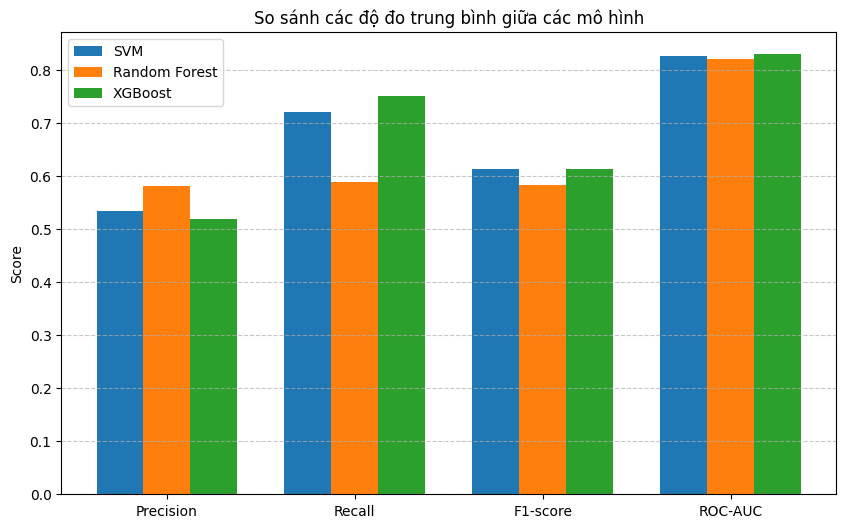

In [6]:
# Vẽ biểu đồ so sánh
metrics = ["Precision", "Recall", "F1-score", "ROC-AUC"]
models_name = list(model_results.keys())

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

for i, model_name in enumerate(models_name):
    values = [model_results[model_name][m] for m in metrics]

    plt.bar(
        x + i*width,
        values,
        width=width,
        label=model_name
    )

# format
plt.xticks(x + width, metrics)
plt.ylabel("Score")
plt.title("So sánh các độ đo trung bình giữa các mô hình")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

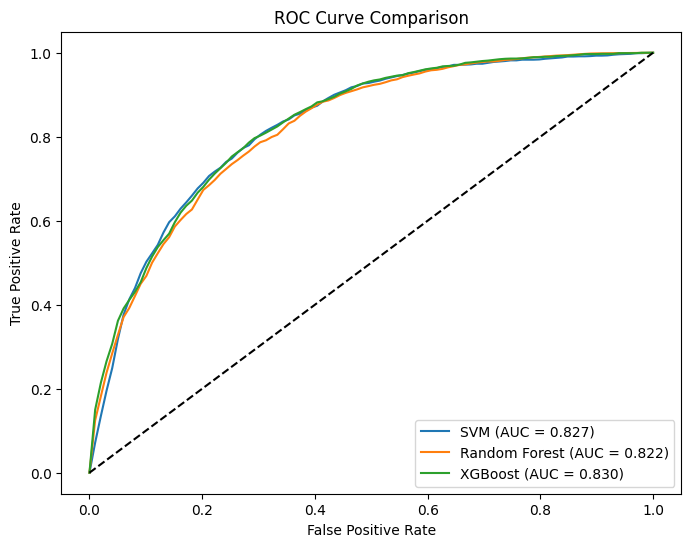

In [7]:
# Biểu đồ ROC Curve
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for model_name, model in models.items():

    tprs = []
    aucs = []
    mean_fpr = np.linspace(0,1,100)

    for train_idx, test_idx in skf.split(X, y):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # SCALE
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # SMOTE
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)

        # TRAIN
        model.fit(X_train, y_train)

        # PROBABILITY
        y_prob = model.predict_proba(X_test)[:,1]

        # ROC
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        # nội suy để lấy mean ROC
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0

        tprs.append(interp_tpr)
        aucs.append(roc_auc)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)

    plt.plot(
        mean_fpr,
        mean_tpr,
        label=f"{model_name} (AUC = {mean_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

/tmp/ipykernel_2512/869666274.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


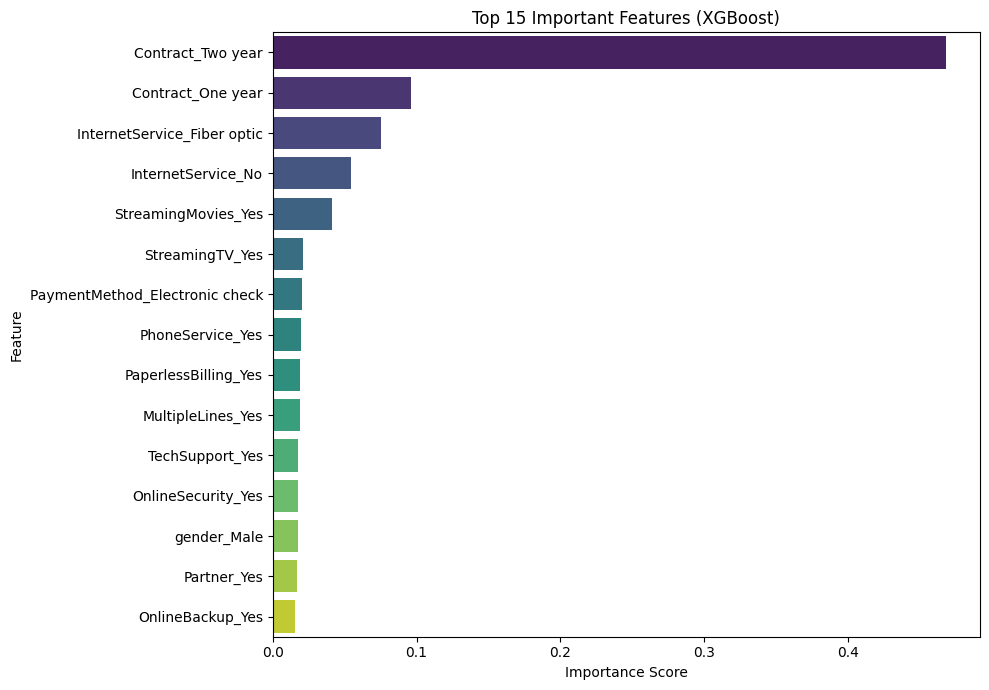

In [8]:
# Feature important
# scale dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

# train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_res, y_res)

# lấy importance
importance = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

top_features = importance_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

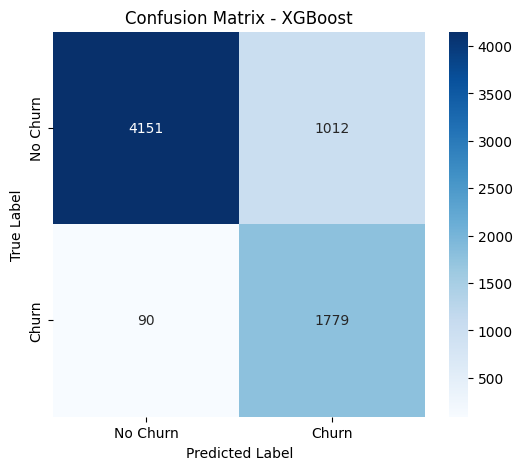

In [9]:
# CONFUSION MATRIX - XGBOOST

from sklearn.metrics import confusion_matrix

# scale dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

# train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_res, y_res)

# dự đoán
y_pred = xgb_model.predict(X_scaled)

# confusion matrix
cm = confusion_matrix(y, y_pred)

# vẽ heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")

plt.show()

In [10]:
import joblib
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
# ==============================
# SMOTE
# ==============================

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("SMOTE done!")

# ==============================
# 1. XGBOOST
# ==============================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_resampled, y_resampled)

# ==============================
# 2. RANDOM FOREST
# ==============================

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_resampled, y_resampled)

# ==============================
# 3. SVM
# ==============================

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_resampled, y_resampled)

print("Đã train xong cả 3 model!")

# ==============================
# LƯU MODEL
# ==============================

joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")

# Lưu feature names (quan trọng cho preprocess)
joblib.dump(X.columns.tolist(), "feature_names.pkl")

print("Đã lưu toàn bộ model thành công!")

SMOTE done!
Đã train xong cả 3 model!
Đã lưu toàn bộ model thành công!
